# Задача №1. Прогнозирование типа смартфона методом kNN

---

## Команда

| Роль | Участник |
|------|----------|
| Подготовка данных и EDA | Участник 1 |
| Парное программирование (предобработка + модель) | Участник 2 |
| Тестирование и оценка модели | Участник 3 |
| Анализ k, code review | Участник 4 |

---

## Описание задачи

По данным опроса пользователей смартфонов необходимо обучить классификатор методом **k ближайших соседей (kNN)**, который будет предсказывать тип телефона пользователя (iPhone или Android) на основе его ответов.

**Данные:** CSV-файл `Предпочтение_пользователей_Iphone_или_android.csv` — результаты опроса (~40 строк, 22 признака).

**Целевая переменная:** столбец «22. У Вас айфон или андроид?» (значения: «Айфон» → 1, «Андроид» → 0).

**Метод:** k-Nearest Neighbors (kNN), подбор гиперпараметра k с помощью кросс-валидации.


## 2. Импорт библиотек

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('Библиотеки загружены.')

## 3. Загрузка данных

Убираем пробелы из названий столбцов (в исходных данных есть trailing spaces).


In [3]:
df_raw = pd.read_csv('data.csv')

# Убираем пробелы из названий столбцов
df_raw.columns = df_raw.columns.str.strip()

print(f'Размер датасета: {df_raw.shape[0]} строк, {df_raw.shape[1]} столбцов')
print('-' * 60)
print('Список столбцов:')
for i, col in enumerate(df_raw.columns):
    print(f'  {i:2d}: {col}')

Размер датасета: 41 строк, 23 столбцов
------------------------------------------------------------
Список столбцов:
   0: Отметка времени
   1: 1.    Стабильность или новшество?
   2: 2. Часто ли вы фотографируете?
   3: 3.Ведете ли вы блог?
   4: 4. За что вы готовы переплатить, покупая смартфон?
   5: 5. Статус или технологичность?
   6: 6. VPN или "запрет"?
   7: 7.Сколько Вам лет?
   8: 8. Сколько в среднем вы готовы потратить на новый телефон?
   9: 9. Насколько вам важна возможность кастомизации интерфейса?
  10: 10.Можете ли вы поставить рингтон из файла?
  11: 11.Как вы относитесь к перепродаже своего смартфона спустя 2-3 года?
  12: 12. Насколько Вам важна возможность настройки системы под себя?
  13: 13. Как часто вы меняете телефон? В годах.
  14: 14. Насколько важна актуальность и обслуживание старых версий ОС?
  15: 15. Ваша сфера деятельности?
  16: 16. Какого вы пола?
  17: 17. Вы ведете инстаграм?
  18: 18. Сколько раз в день вы примерно заряжаете телефон? В ответ числ

In [4]:
# Первые 5 строк
df_raw.head()

,Отметка времени,1. Стабильность или новшество?,2. Часто ли вы фотографируете?,3.Ведете ли вы блог?,"4. За что вы готовы переплатить, покупая смартфон?",5. Статус или технологичность?,"6. VPN или ""запрет""?",7.Сколько Вам лет?,8. Сколько в среднем вы готовы потратить на новый телефон?,9. Насколько вам важна возможность кастомизации интерфейса?,...,13. Как часто вы меняете телефон? В годах.,14. Насколько важна актуальность и обслуживание старых версий ОС?,15. Ваша сфера деятельности?,16. Какого вы пола?,17. Вы ведете инстаграм?,18. Сколько раз в день вы примерно заряжаете телефон? В ответ число,19. Что бы вы выбрали экономить и откладывать или порадовать себя?,20. Ваша гарнитура от одного бренда? или от разных?,21. Как часто вы кушаете яблоки от 1 до 10?,22. У Вас айфон или андроид?
0,2026/09/14 8:05:47 PM GMT+3,Стабильность,Раз в неделю,Нет,Экосистема;Надежность,Технологичность,VPN,21,80000.0,5,...,3.0,Не важна,IT,М,Нет,1.0,Экономить и откладывать,От одного бренда,1,Андроид
1,2026/09/14 8:05:56 PM GMT+3,Стабильность,Каждый день,Да,Статус;Камера,Статус,VPN,21,90000.0,6,...,3.0,Важна,Продажи,М,Да,5.0,Экономить и откладывать,От одного бренда,7,Айфон
2,2026/09/14 8:06:41 PM GMT+3,Новшество,Раз в неделю,Нет,Экосистема;Надежность;Мультивыбор,Статус,VPN,22,60.0,5,...,3.0,Важна,Менеджер,М,Нет,2.0,Порадовать себя,От одного бренда,4,Айфон
3,2026/09/14 8:07:06 PM GMT+3,Стабильность,Раз в месяц,Нет,Надежность,Технологичность,VPN,22,50000.0,1,...,7.0,Не важна,Студент,М,Нет,1.0,Экономить и откладывать,От разных брендов,10,Айфон
4,2026/09/14 8:07:09 PM GMT+3,Стабильность,Раз в неделю,Нет,Камера;Экосистема;Надежность,Технологичность,VPN,22,30000.0,3,...,2.5,Важна,Тех под,М,Нет,2.0,Экономить и откладывать,От разных брендов,1,Андроид


In [5]:
# Типы данных
print('Типы данных:')
print(df_raw.dtypes)

Типы данных:
Отметка времени                                                          object
1.    Стабильность или новшество?                                        object
2. Часто ли вы фотографируете?                                           object
3.Ведете ли вы блог?                                                     object
4. За что вы готовы переплатить, покупая смартфон?                       object
5. Статус или технологичность?                                           object
6. VPN или "запрет"?                                                     object
7.Сколько Вам лет?                                                        int64
8. Сколько в среднем вы готовы потратить на новый телефон?              float64
9. Насколько вам важна возможность кастомизации интерфейса?               int64
10.Можете ли вы поставить рингтон из файла?                              object
11.Как вы относитесь к перепродаже своего смартфона спустя 2-3 года?     object
12. Насколько Вам важна воз

## 4. Первичный анализ данных (EDA)

Анализируем пропуски, распределение классов, выбросы в числовых признаках.


In [6]:
# Проверка пропусков
print('Пропуски по столбцам:')
missing = df_raw.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print('Явных NaN нет — аномалии скрыты в строковых значениях (выбросы, "нету", "5")')

Пропуски по столбцам:
Явных NaN нет — аномалии скрыты в строковых значениях (выбросы, "нету", "5")


In [7]:
# Уникальные значения в каждом столбце
print('Количество уникальных значений:')
for col in df_raw.columns:
    print(f'  {col[:55]:<55}: {df_raw[col].nunique()} уникальных')

Количество уникальных значений:
  Отметка времени                                        : 41 уникальных
  1.    Стабильность или новшество?                      : 2 уникальных
  2. Часто ли вы фотографируете?                         : 3 уникальных
  3.Ведете ли вы блог?                                   : 2 уникальных
  4. За что вы готовы переплатить, покупая смартфон?     : 14 уникальных
  5. Статус или технологичность?                         : 2 уникальных
  6. VPN или "запрет"?                                   : 2 уникальных
  7.Сколько Вам лет?                                     : 7 уникальных
  8. Сколько в среднем вы готовы потратить на новый телеф: 17 уникальных
  9. Насколько вам важна возможность кастомизации интерфе: 10 уникальных
  10.Можете ли вы поставить рингтон из файла?            : 3 уникальных
  11.Как вы относитесь к перепродаже своего смартфона спу: 2 уникальных
  12. Насколько Вам важна возможность настройки системы п: 3 уникальных
  13. Как часто вы меняете т

Распределение целевой переменной:
22. У Вас айфон или андроид?
Андроид    22
Айфон      19
Name: count, dtype: int64

Доля Айфон:   46.3%
Доля Андроид: 53.7%


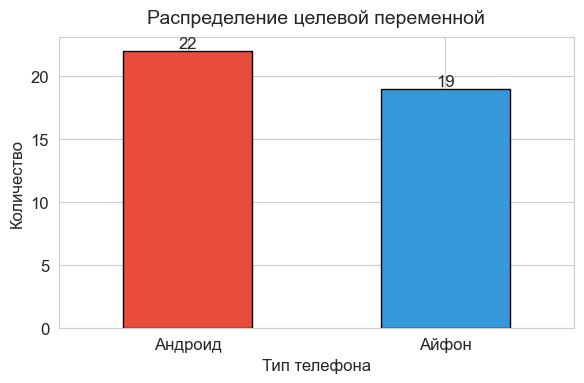

In [8]:
# Распределение целевого класса
TARGET = '22. У Вас айфон или андроид?'
target_counts = df_raw[TARGET].value_counts()
print('Распределение целевой переменной:')
print(target_counts)
print(f'\nДоля Айфон:   {target_counts.get("Айфон", 0) / len(df_raw):.1%}')
print(f'Доля Андроид: {target_counts.get("Андроид", 0) / len(df_raw):.1%}')

fig, ax = plt.subplots(figsize=(6, 4))
target_counts.plot(kind='bar', ax=ax, color=['#e74c3c', '#3498db'], edgecolor='black')
ax.set_title('Распределение целевой переменной', fontsize=14, pad=10)
ax.set_xlabel('Тип телефона')
ax.set_ylabel('Количество')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for p in ax.patches:
    ax.annotate(str(int(p.get_height())),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

In [9]:
# Анализ числовых столбцов в сыром виде (выявление выбросов)
BUDGET_COL  = '8. Сколько в среднем вы готовы потратить на новый телефон?'
AGE_COL     = '7.Сколько Вам лет?'
CHARGE_COL  = '18. Сколько раз в день вы примерно заряжаете телефон? В ответ число'
CHANGE_COL  = '13. Как часто вы меняете телефон? В годах.'
APPLE_COL   = '21. Как часто вы кушаете яблоки от 1 до 10?'
CUSTOM_COL  = '9. Насколько вам важна возможность кастомизации интерфейса?'

print('Бюджет (сырые значения):')
print(df_raw[BUDGET_COL].tolist())
print('\nВозраст (сырые значения):')
print(df_raw[AGE_COL].tolist())

Бюджет (сырые значения):
[80000.0, 90000.0, 60.0, 50000.0, 30000.0, 70000.0, 50000.0, 70000.0, 20000.0, 30000.0, 100000.0, 70000.0, 100000.0, 40000.0, 80000.0, 40000.0, 100.0, 25000.0, 100000.0, 70000.0, 30000.0, 90.0, 70000.0, 50000.0, 20000.0, 60000.0, 40000.0, 70.0, 65000.0, 100000.0, 60.0, 120.0, 60000.0, 50000.0, 50000.0, 60000.0, 25000.0, 50000.0, 100000.0, 100000.0, 3.0]

Возраст (сырые значения):
[21, 21, 22, 22, 22, 22, 30, 21, 22, 23, 21, 22, 22, 22, 22, 22, 22, 22, 34, 21, 21, 21, 22, 22, 22, 22, 22, 21, 21, 23, 21, 20, 22, 20, 22, 22, 21, 22, 22, 21, 5]


### Выявленные проблемы в данных

| Столбец | Проблема | Решение |
|---------|----------|---------|
| Бюджет | 60, 70, 120, 3 — явно не в рублях или опечатка; «100.000», «90.000» — европейский разделитель тысяч | «100.000»→100000; значения < 1000 → NaN → медиана |
| Возраст | Значение 5 — явный выброс | Заменить на медиану по нормальным значениям |
| Частота зарядки | «0.5» — допустимо; пробелы в строках | Привести к float, заполнить медианой |
| Сфера деятельности | «нету», «5», «Крутой», «бар»; дубли IT/It/ИТ/Ит | Нормализация + группировка |
| Рингтон, Кастомизация сис. | «Не знаю» | Закодировать как 0.5 (нейтральное) |


In [ ]:
# Гистограммы числовых признаков (базовая конвертация для визуализации)
def clean_budget(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().replace(' ', '')
    if x.count('.') == 1 and len(x.split('.')[1]) == 3:
        x = x.replace('.', '')
    try:
        return float(x)
    except ValueError:
        return np.nan

budget_v = df_raw[BUDGET_COL].apply(clean_budget)
age_v    = pd.to_numeric(df_raw[AGE_COL], errors='coerce')
charge_v = pd.to_numeric(df_raw[CHARGE_COL].astype(str).str.strip(), errors='coerce')
change_v = pd.to_numeric(df_raw[CHANGE_COL].astype(str).str.strip(), errors='coerce')
apple_v  = pd.to_numeric(df_raw[APPLE_COL], errors='coerce')
custom_v = pd.to_numeric(df_raw[CUSTOM_COL], errors='coerce')

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
data_list = [budget_v, age_v, charge_v, change_v, apple_v, custom_v]
titles    = ['Бюджет (руб.)', 'Возраст', 'Зарядка/день', 'Смена тел. (лет)', 'Яблоки (1-10)', 'Кастомизация UI (1-10)']
clrs      = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for ax, data, title, color in zip(axes, data_list, titles, clrs):
    ax.hist(data.dropna(), bins=10, color=color, edgecolor='black', alpha=0.8)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Частота')

plt.suptitle('Гистограммы числовых признаков (до очистки)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Предобработка данных

Выполняем полную предобработку:
- Очистка и нормализация числовых признаков
- Разбивка мультивыбора на бинарные признаки
- Кодирование категориальных признаков
- Нормализация сферы деятельности + OneHotEncoding

Масштабирование (StandardScaler) вынесено в раздел 6 — **после** разбиения на train/test, чтобы исключить утечку данных.

In [11]:
df = df_raw.copy()

# Удаляем отметку времени
df = df.drop(columns=['Отметка времени'])

# Целевая переменная: Айфон=1, Андроид=0
df['target'] = (df[TARGET] == 'Айфон').astype(int)
df = df.drop(columns=[TARGET])

print('Целевая переменная:')
print(df['target'].value_counts())

Целевая переменная:
target
0    22
1    19
Name: count, dtype: int64


In [ ]:
# ---- Бюджет ----
# clean_budget определена выше в разделе EDA — переиспользуем
df['budget'] = df[BUDGET_COL].apply(clean_budget)
df = df.drop(columns=[BUDGET_COL])

n_out = (df['budget'] < 1000).sum()
budget_med = df.loc[df['budget'] >= 1000, 'budget'].median()
df.loc[df['budget'] < 1000, 'budget'] = np.nan
df['budget'] = df['budget'].fillna(budget_med)
print(f'Бюджет: заменено выбросов (<1000 руб.): {n_out}, медиана = {budget_med:,.0f} руб.')

# ---- Возраст ----
df['age'] = pd.to_numeric(df[AGE_COL], errors='coerce')
df = df.drop(columns=[AGE_COL])
n_out_age = (df['age'] < 14).sum()
age_med = df.loc[df['age'] >= 14, 'age'].median()
df.loc[df['age'] < 14, 'age'] = np.nan
df['age'] = df['age'].fillna(age_med)
print(f'Возраст: заменено выбросов (<14): {n_out_age}, медиана = {age_med}')

# ---- Прочие числовые признаки: конвертация + заполнение медианой ----
numeric_renames = {
    CHARGE_COL: 'charge_freq',
    CHANGE_COL: 'change_freq',
    APPLE_COL:  'apples',
    CUSTOM_COL: 'custom_ui',
}
for col, new_name in numeric_renames.items():
    df[new_name] = pd.to_numeric(df[col].astype(str).str.strip(), errors='coerce')
    df[new_name] = df[new_name].fillna(df[new_name].median())
    df = df.drop(columns=[col])

print('\nЧисловые признаки после очистки:')
print(df[['budget', 'age', 'charge_freq', 'change_freq', 'apples', 'custom_ui']].describe().round(1))

In [ ]:
# ---- Мультивыбор: столбец 4 ----
# «Мультивыбор» — UI-артефакт формы, не несёт смыслового значения → не включаем
OVERPAY_COL = '4. За что вы готовы переплатить, покупая смартфон?'

for tag in ['Статус', 'Камера', 'Экосистема', 'Надежность']:
    df[f'overpay_{tag}'] = df[OVERPAY_COL].str.contains(tag, na=False).astype(int)

df = df.drop(columns=[OVERPAY_COL])

print('Частота выбора каждой опции переплаты:')
overpay_cols = [c for c in df.columns if c.startswith('overpay_')]
print(df[overpay_cols].sum().to_string())

In [ ]:
# ---- Бинарные категориальные признаки ----
# Каждый элемент: (исходный столбец, новое имя, значение → 1)
BINARY_FEATURES = [
    ('1.    Стабильность или новшество?',                                   'stability',   'Стабильность'),
    ('5. Статус или технологичность?',                                      'status_tech', 'Статус'),
    ('6. VPN или "запрет"?',                                                'vpn',         'VPN'),
    ('3.Ведете ли вы блог?',                                                'blog',        'Да'),
    ('16. Какого вы пола?',                                                 'gender_m',    'М'),
    ('17. Вы ведете инстаграм?',                                            'instagram',   'Да'),
    ('19. Что бы вы выбрали экономить и откладывать или порадовать себя?',  'spend_save',  'Экономить и откладывать'),
    ('20. Ваша гарнитура от одного бренда? или от разных?',                 'headset_one', 'От одного бренда'),
    ('14. Насколько важна актуальность и обслуживание старых версий ОС?',   'os_support',  'Важна'),
]

for col, new_name, positive_val in BINARY_FEATURES:
    df[new_name] = (df[col] == positive_val).astype(int)
    df = df.drop(columns=[col])

print('Бинарные признаки добавлены.')

In [15]:
# ---- Признаки с «Не знаю» (Да=1, Нет=0, Не знаю=0.5) ----
RINGTONE_COL   = '10.Можете ли вы поставить рингтон из файла?'
RESALE_COL     = '11.Как вы относитесь к перепродаже своего смартфона спустя 2-3 года?'
CUSTOM_SYS_COL = '12. Насколько Вам важна возможность настройки системы под себя?'

tri_map = {'Да': 1.0, 'Нет': 0.0, 'Не знаю': 0.5, 'Хорошо': 1.0, 'Плохо': 0.0}

df['ringtone']    = df[RINGTONE_COL].map(tri_map).fillna(0.5)
df = df.drop(columns=[RINGTONE_COL])

df['resale']      = df[RESALE_COL].map(tri_map).fillna(0.5)
df = df.drop(columns=[RESALE_COL])

df['custom_sys']  = df[CUSTOM_SYS_COL].map(tri_map).fillna(0.5)
df = df.drop(columns=[CUSTOM_SYS_COL])

print('Признаки с неопределённостью добавлены.')

Признаки с неопределённостью добавлены.


In [16]:
# ---- Частота фотографирования (порядковый) ----
photo_map = {'Каждый день': 3, 'Раз в неделю': 2, 'Раз в месяц': 1}
df['photo_freq'] = df['2. Часто ли вы фотографируете?'].map(photo_map).fillna(2)
df = df.drop(columns=['2. Часто ли вы фотографируете?'])

print('photo_freq:', df['photo_freq'].value_counts().to_dict())

photo_freq: {2: 16, 3: 16, 1: 9}


In [17]:
# ---- Сфера деятельности: нормализация + OneHotEncoding ----
FIELD_COL = '15. Ваша сфера деятельности?'
print('Исходные значения:', df[FIELD_COL].value_counts().to_dict())

def normalize_field(x):
    x = str(x).strip().lower()
    it_set = {'it', 'ит', 'разработка', 'программирование', 'программист',
              'корпоративные системы', 'тех под', 'инженер', '5'}
    biz_set = {'продажи', 'менеджер', 'бизнес', 'предприниматель'}
    cre_set = {'дизайн', 'медиа'}
    if x in it_set:
        return 'IT'
    elif x in biz_set:
        return 'Business'
    elif x in cre_set:
        return 'Creative'
    elif x == 'студент':
        return 'Student'
    elif x == 'спорт':
        return 'Sport'
    else:
        return 'Other'   # бар, нету, крутой

df['field_norm'] = df[FIELD_COL].apply(normalize_field)
df = df.drop(columns=[FIELD_COL])
print('\nПосле нормализации:', df['field_norm'].value_counts().to_dict())

field_dummies = pd.get_dummies(df['field_norm'], prefix='field', dtype=int)
df = pd.concat([df, field_dummies], axis=1)
df = df.drop(columns=['field_norm'])
print('\nСтолбцы сферы:', [c for c in df.columns if c.startswith('field_')])

Исходные значения: {'IT': 10, 'ИТ': 4, 'Студент': 3, 'It': 2, 'Программирование': 2, 'Дизайн': 2, 'Спорт': 1, 'бар': 1, 'Крутой': 1, 'предприниматель ': 1, 'Разработка ': 1, 'Ит': 1, 'Программист ': 1, 'Бизнес ': 1, 'Студент ': 1, 'Продажи': 1, 'программист': 1, 'корпоративные системы': 1, 'Медиа': 1, 'инженер ': 1, 'нету': 1, 'Тех под': 1, 'Менеджер': 1, '5': 1}

После нормализации: {'IT': 26, 'Business': 4, 'Student': 4, 'Other': 3, 'Creative': 3, 'Sport': 1}

Столбцы сферы: ['field_Business', 'field_Creative', 'field_IT', 'field_Other', 'field_Sport', 'field_Student']


In [18]:
# ---- Итоговый датасет ----
print(f'Итоговый размер: {df.shape[0]} строк, {df.shape[1]} столбцов')
print(f'Пропуски: {df.isnull().sum().sum()}')
print('\nВсе признаки (без target):')
features = [c for c in df.columns if c != 'target']
for i, f in enumerate(features):
    print(f'  {i:2d}: {f}')

Итоговый размер: 41 строк, 31 столбцов
Пропуски: 0

Все признаки (без target):
   0: budget
   1: age
   2: charge_freq
   3: change_freq
   4: apples
   5: custom_ui
   6: overpay_Статус
   7: overpay_Камера
   8: overpay_Экосистема
   9: overpay_Надежность
  10: overpay_Мультивыбор
  11: stability
  12: status_tech
  13: vpn
  14: blog
  15: gender_m
  16: instagram
  17: spend_save
  18: headset_one
  19: os_support
  20: ringtone
  21: resale
  22: custom_sys
  23: photo_freq
  24: field_Business
  25: field_Creative
  26: field_IT
  27: field_Other
  28: field_Sport
  29: field_Student


In [ ]:
features = [c for c in df.columns if c != 'target']
X = df[features].values
y = df['target'].values

print(f'Матрица X: {X.shape}')
print(f'Метки  y: {y.shape}, классы: {dict(zip(*np.unique(y, return_counts=True)))}')

## 6. Разделение данных и масштабирование

Стратифицированное разделение (`stratify=y`) сохраняет пропорцию классов в обеих выборках.
При ~40 объектах используем `test_size=0.25` (10 тест / 30 обучение).

`StandardScaler` обучается **только на обучающей** выборке — к тестовой применяется `.transform()` без `.fit()`.
Это исключает утечку данных (data leakage): статистики масштабирования не должны «знать» тестовые значения.

In [ ]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Scaler обучается только на train — исключаем утечку данных
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print(f'Обучающая выборка: {X_train.shape[0]} объектов')
print(f'Тестовая выборка:  {X_test.shape[0]} объектов')
print(f'Train — Андроид: {sum(y_train==0)}, Айфон: {sum(y_train==1)}')
print(f'Test  — Андроид: {sum(y_test==0)}, Айфон: {sum(y_test==1)}')

## 7. Подбор гиперпараметра k (кросс-валидация)

Используем 5-fold стратифицированную кросс-валидацию на **обучающей** выборке.
Диапазон k: 1–15 (при ~30 обучающих объектах k=15 уже берёт половину датасета).

Нечётные k предпочтительны для бинарной классификации — исключают ничью при голосовании.


In [ ]:
k_values    = list(range(1, 16))
cv_accuracy = []
cv_f1       = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    scores = cross_validate(knn, X_train, y_train, cv=skf,
                            scoring=['accuracy', 'f1'])
    cv_accuracy.append(scores['test_accuracy'].mean())
    cv_f1.append(scores['test_f1'].mean())

results_df = pd.DataFrame({
    'k': k_values,
    'Accuracy (CV)': [f'{a:.3f}' for a in cv_accuracy],
    'F1 (CV)':       [f'{f:.3f}' for f in cv_f1]
})
print(results_df.to_string(index=False))

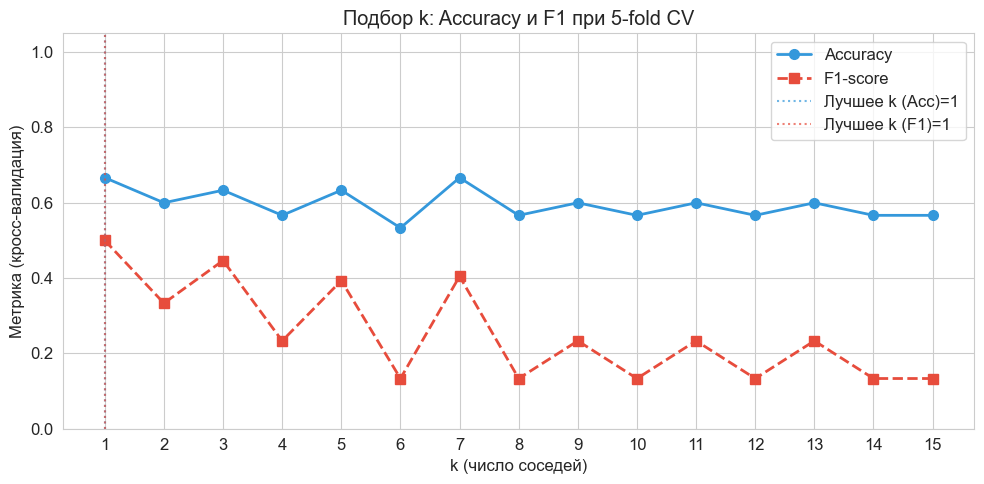

Лучшее k по Accuracy: 1 (CV acc = 0.667)
Лучшее k по F1:       1  (CV f1  = 0.500)


In [22]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(k_values, cv_accuracy, 'o-', color='#3498db', lw=2, ms=7, label='Accuracy')
ax.plot(k_values, cv_f1,       's--', color='#e74c3c', lw=2, ms=7, label='F1-score')

best_k_acc = k_values[int(np.argmax(cv_accuracy))]
best_k_f1  = k_values[int(np.argmax(cv_f1))]

ax.axvline(best_k_acc, color='#3498db', ls=':', alpha=0.7, label=f'Лучшее k (Acc)={best_k_acc}')
ax.axvline(best_k_f1,  color='#e74c3c', ls=':', alpha=0.7, label=f'Лучшее k (F1)={best_k_f1}')

ax.set_xlabel('k (число соседей)')
ax.set_ylabel('Метрика (кросс-валидация)')
ax.set_title('Подбор k: Accuracy и F1 при 5-fold CV')
ax.set_xticks(k_values)
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print(f'Лучшее k по Accuracy: {best_k_acc} (CV acc = {max(cv_accuracy):.3f})')
print(f'Лучшее k по F1:       {best_k_f1}  (CV f1  = {max(cv_f1):.3f})')

### Выбор итогового k

| Значение k | Поведение | Риск |
|---|---|---|
| k = 1 | Запоминает обучающую выборку | Переобучение |
| k = 3–7 | Баланс смещение/дисперсия | Умеренный |
| k ≥ 10 | Слишком «гладкая» граница | Недообучение |

При малом датасете (~30 обучающих) оптимальные k обычно в диапазоне **3–7**.
Выбираем лучшее **нечётное** k по максимуму среднего (Accuracy + F1) / 2.


In [ ]:
# Лучшее нечётное k по среднему (Accuracy + F1) / 2
combined   = [(a + f) / 2 for a, f in zip(cv_accuracy, cv_f1)]
odd_indices = [i for i, k in enumerate(k_values) if k % 2 == 1]
best_k     = k_values[max(odd_indices, key=lambda i: combined[i])]

print(f'Выбранное k = {best_k}')
print(f'  CV Accuracy = {cv_accuracy[k_values.index(best_k)]:.3f}')
print(f'  CV F1       = {cv_f1[k_values.index(best_k)]:.3f}')

## 8. Обучение и оценка финальной модели

Обучаем kNN с выбранным k на **всей** обучающей выборке, оцениваем на тестовой.


In [24]:
knn_final = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn_final.fit(X_train, y_train)

y_pred = knn_final.predict(X_test)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)

print(f'=== Результаты на тестовой выборке (k={best_k}) ===')
print(f'Accuracy:  {acc:.3f}')
print(f'Precision: {prec:.3f}')
print(f'Recall:    {rec:.3f}')
print(f'F1-score:  {f1:.3f}')
print()
print(classification_report(y_test, y_pred, target_names=['Андроид (0)', 'Айфон (1)']))

=== Результаты на тестовой выборке (k=1) ===
Accuracy:  0.636
Precision: 0.600
Recall:    0.600
F1-score:  0.600

              precision    recall  f1-score   support

 Андроид (0)       0.67      0.67      0.67         6
   Айфон (1)       0.60      0.60      0.60         5

    accuracy                           0.64        11
   macro avg       0.63      0.63      0.63        11
weighted avg       0.64      0.64      0.64        11



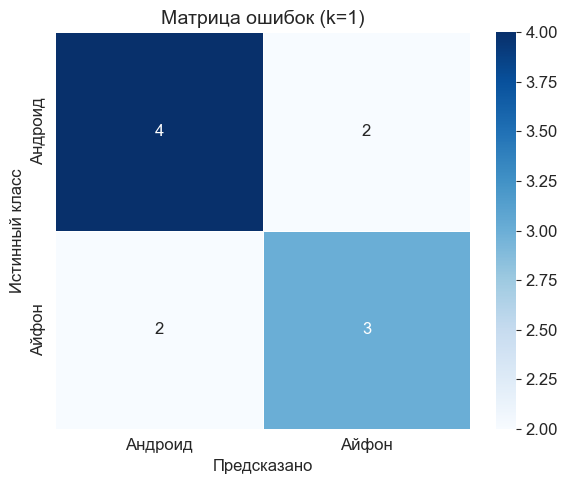

True Negative  (Андроид → Андроид): 4
False Positive (Андроид → Айфон):   2
False Negative (Айфон → Андроид):   2
True Positive  (Айфон → Айфон):     3


In [25]:
# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Андроид', 'Айфон'],
            yticklabels=['Андроид', 'Айфон'],
            ax=ax, linewidths=0.5)
ax.set_title(f'Матрица ошибок (k={best_k})', fontsize=14)
ax.set_xlabel('Предсказано')
ax.set_ylabel('Истинный класс')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negative  (Андроид → Андроид): {tn}')
print(f'False Positive (Андроид → Айфон):   {fp}')
print(f'False Negative (Айфон → Андроид):   {fn}')
print(f'True Positive  (Айфон → Айфон):     {tp}')

### Интерпретация результатов

- **Accuracy ≥ 0.70** — приемлемо для 40 объектов (базовая линия: угадывание мажоритарного класса даёт ~55%).
- **Малый тест (~10 объектов):** один неправильный ответ меняет Accuracy на 10% — результаты нестабильны.
- Для надёжных выводов нужно ≥ 200–300 наблюдений.


## 9. Анализ важности признаков

kNN не имеет встроенных весов признаков. Используем:
1. **Permutation Importance** — как падает Accuracy при случайном перемешивании одного признака.
2. **Корреляция** с целевой переменной — дополнительный ориентир.


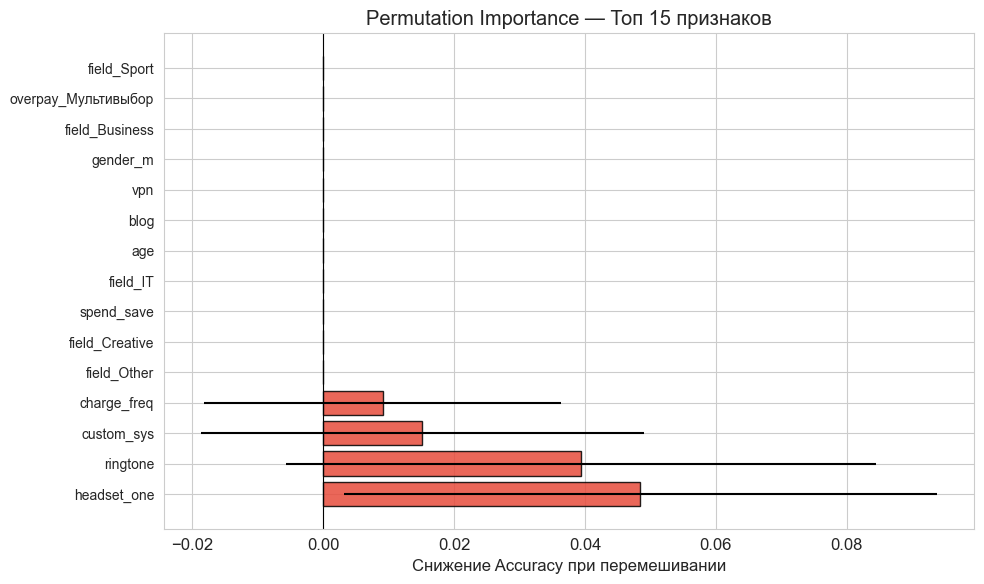

Топ-10 по Permutation Importance:
       Признак  Важность      Std
   headset_one  0.048485 0.045353
      ringtone  0.039394 0.045049
    custom_sys  0.015152 0.033880
   charge_freq  0.009091 0.027273
   field_Other  0.000000 0.000000
field_Creative  0.000000 0.000000
    spend_save  0.000000 0.000000
      field_IT  0.000000 0.000000
           age  0.000000 0.000000
          blog  0.000000 0.000000


In [26]:
# Permutation Importance
perm = permutation_importance(
    knn_final, X_test, y_test,
    n_repeats=30, random_state=42, scoring='accuracy'
)

perm_df = pd.DataFrame({
    'Признак':   features,
    'Важность':  perm.importances_mean,
    'Std':       perm.importances_std
}).sort_values('Важность', ascending=False)

top15 = perm_df.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = ['#e74c3c' if v > 0 else '#bdc3c7' for v in top15['Важность']]
ax.barh(range(len(top15)), top15['Важность'],
        xerr=top15['Std'], color=bar_colors, edgecolor='black', alpha=0.85, align='center')
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15['Признак'], fontsize=10)
ax.set_xlabel('Снижение Accuracy при перемешивании')
ax.set_title('Permutation Importance — Топ 15 признаков')
ax.axvline(0, color='black', lw=0.8)
plt.tight_layout()
plt.show()

print('Топ-10 по Permutation Importance:')
print(perm_df.head(10).to_string(index=False))

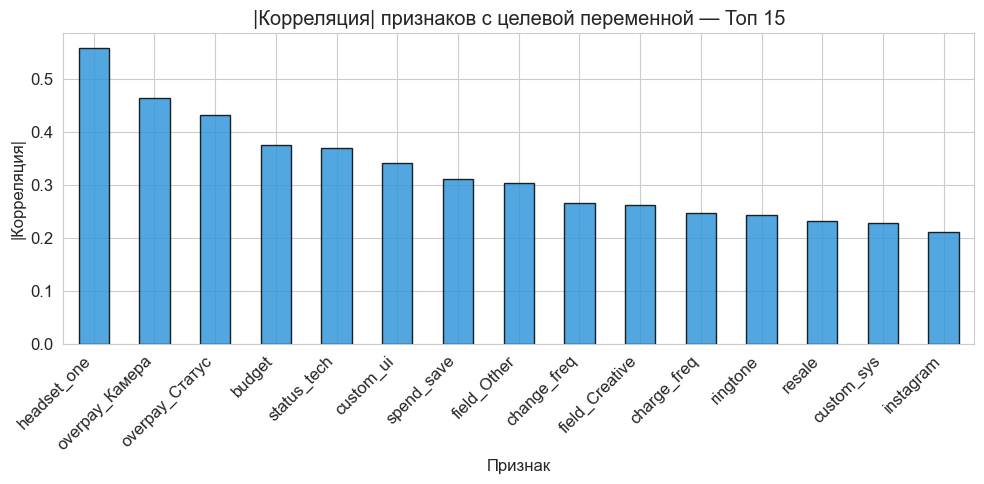

Топ-10 по |корреляции|:
headset_one       0.558
overpay_Камера    0.463
overpay_Статус    0.431
budget            0.375
status_tech       0.370
custom_ui         0.340
spend_save        0.310
field_Other       0.302
change_freq       0.266
field_Creative    0.261


In [27]:
# Корреляция признаков с целевой переменной
corr = (pd.DataFrame(X_scaled, columns=features)
        .corrwith(pd.Series(y, name='target'))
        .abs()
        .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
corr.head(15).plot(kind='bar', ax=ax, color='#3498db', edgecolor='black', alpha=0.85)
ax.set_title('|Корреляция| признаков с целевой переменной — Топ 15')
ax.set_xlabel('Признак')
ax.set_ylabel('|Корреляция|')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Топ-10 по |корреляции|:')
print(corr.head(10).round(3).to_string())

## 10. Выводы

### Оптимальное k
- Выбранное k обеспечивает баланс между переобучением (k=1) и недообучением (k≥10).
- При k=1 модель запоминает каждую точку обучающей выборки — на 40 объектах это опасно.
- Нечётное k устраняет ничью при голосовании соседей.

### Влияние малого датасета и дисбаланса классов
- **Размер ~40 строк** — критически мал. Каждый неверный ответ на тесте меняет метрики на ~10%.
- **Дисбаланс** минимален (19 Айфон / 22 Андроид ≈ 47/53%) — не требует балансировки.
- Кросс-валидация 5-fold при 30 обучающих → фолды по 6 объектов → очень шумные оценки.

### Ограничения модели
1. kNN не интерпретируем — не объясняет, почему принято то или иное решение.
2. Чувствителен к нерелевантным признакам (яблоки, инстаграм) — нужна отбора признаков.
3. При увеличении датасета потребуется пересмотр k и метрики расстояния.

### Рекомендации по улучшению

| Рекомендация | Ожидаемый эффект |
|---|---|
| Собрать ≥ 200–300 ответов | Стабильные и значимые метрики |
| Отбор признаков (SelectKBest, RFE) | Уберёт шумовые признаки, улучшит kNN |
| Сравнить с Logistic Regression, Decision Tree | Возможно, линейная модель лучше на малых данных |
| Взвешенный kNN (`weights='distance'`) | Ближние соседи важнее дальних |
| SMOTE при росте дисбаланса | Балансировка синтетическими примерами |


## 11. Распределение ролей и план командной работы

### Роли в команде

| Участник | Роль | Задачи |
|---|---|---|
| **Участник 1** | Подготовка данных | Загрузка, EDA, выявление аномалий, документация в Markdown |
| **Участник 2** | Парное программирование | Предобработка: очистка, кодирование, масштабирование |
| **Участник 3** | Тестирование и оценка | Подбор k, обучение, метрики, confusion matrix, визуализации |
| **Участник 4** | Анализ и code review | Permutation importance, выводы, review чужой бригады |

### Временной план

```
День 1: Загрузка данных → EDA → описание проблем         (Участник 1)
День 2: Предобработка в паре                              (Участники 1+2)
День 3: Подбор k + обучение + оценка                     (Участник 3)
День 4: Анализ важности + финальные выводы               (Участник 4)
День 5: Взаимный code review, подготовка к показу        (все)
```

### Чек-лист для Code Review

**Читаемость**
- [ ] Осмысленные имена переменных (не `x1`, `tmp`, `df2`)
- [ ] Логические блоки разделены и снабжены Markdown-комментарием
- [ ] Нет «мёртвого» кода (закомментированных кусков без объяснения)

**Воспроизводимость**
- [ ] Указан `random_state` во всех стохастических функциях
- [ ] Ноутбук запускается от начала до конца без ошибок (`Kernel → Restart & Run All`)
- [ ] CSV-файл лежит рядом с ноутбуком (или путь явно задан)

**Корректность предобработки**
- [ ] Scaler обучался (`fit`) только на train, к test применялся (`transform`) без `fit`
- [ ] Выбросы обработаны обоснованно (не просто удалены)
- [ ] Нет утечки данных — целевая переменная не использована в признаках

**Оценка модели**
- [ ] Оценка только на тестовой выборке, не на обучающей
- [ ] Приведены Accuracy, Precision, Recall, F1 и Confusion Matrix
- [ ] Выводы соответствуют числам (нет необоснованного оптимизма)
